# Predicting Smartphone Addiction — Full Pipeline

**Goal:** predict `addicted_label` (a probability between 0 and 1) for each `id` in the test set,
and be evaluated using **ROC-AUC** (Area Under the ROC Curve).

**What this notebook does, step by step:**
1. Load data
2. Explore data (understand missing values, noise, distributions)
3. Clean data (missing values, outliers/noise, encoding)
4. Feature engineering
5. Split train data into a training part and a validation part (so we can measure ROC-AUC ourselves, since the real test set has no labels)
6. Train **5 different models**
7. Evaluate every model with ROC-AUC on the validation part
8. Save **one submission file per model** in the format `id,addicted_label`
9. Explanation of which parameter to change in each model, and in which direction, to try to improve the ROC-AUC

> Every code cell has comments explaining **what** each line does and **why**.


## 0. Environment Setup (doing this OUTSIDE the notebook, in your terminal)

Run these commands once, before opening this notebook, to create a clean conda environment with everything installed.

```bash
# 1) Create a new conda environment named "selfProjects" with Python 3.11
conda create -n  python=3.11 -y

# 2) Activate it
conda activate selfProjects

# 3) Install the packages we need
pip install pandas numpy scikit-learn matplotlib seaborn xgboost lightgbm jupyter notebook

# 4) Launch Jupyter from inside the environment
jupyter notebook
```

**What each package is for:**
- `pandas`, `numpy` → loading and manipulating the data
- `scikit-learn` → cleaning tools (imputers, scalers, encoders), models, and the ROC-AUC metric
- `matplotlib`, `seaborn` → plots to explore missing values / distributions
- `xgboost`, `lightgbm` → two extra, very strong tree-boosting models (used as 2 of our 5 models)
- `jupyter`, `notebook` → to run this notebook

If you prefer `pip` + `venv` instead of conda:
```bash
python -m venv selfProjects_env
source selfProjects_env/bin/activate      # on Windows: addiction_env\Scripts\activate
pip install pandas numpy scikit-learn matplotlib seaborn xgboost lightgbm jupyter notebook
```


## 1. Imports

Standard libraries for data handling, plotting, preprocessing, modeling and evaluation.


In [1]:
# --- Data handling ---
import pandas as pd
import numpy as np

# --- Plotting (used only to LOOK at the data, not required for the model) ---
import matplotlib.pyplot as plt
import seaborn as sns

# --- Preprocessing tools ---
from sklearn.impute import SimpleImputer          # fills missing values
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split

# --- Models (we will use at least 5) ---
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# --- Evaluation metric required by the competition ---
from sklearn.metrics import roc_auc_score, roc_curve

import warnings
warnings.filterwarnings("ignore")   # keeps the notebook output clean

# Make results reproducible: every time we use "random_state=RANDOM_STATE"
# we will get the exact same split / same model results.
RANDOM_STATE = 42


## 2. Load the data


- `train.csv` → 691369 rows, includes the `addicted_label` column (0/1, the truth)
- `test.csv` → 296302 rows, **no** `addicted_label` column — this is what we must predict

Change `TRAIN_PATH` / `TEST_PATH` below to match where your files actually are.


In [2]:
TRAIN_PATH = "./train.csv"   
TEST_PATH  = "./test.csv"    

train_df = pd.read_csv(TRAIN_PATH)
test_df  = pd.read_csv(TEST_PATH)

print("train shape:", train_df.shape)   # expect (691369, 13)
print("test shape :", test_df.shape)    # expect (296302, 12)  (no label column)

train_df.head()


train shape: (691369, 14)
test shape : (296302, 13)


,id,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact,addicted_label
0,0,24.0,NaN,1.83,1.59,2.11,7.46,122.0,38.0,8.63,Male,Medium,No,1
1,1,19.0,5.97,1.08,NaN,3.03,8.22,76.0,19.0,NaN,Female,Medium,No,0
2,2,18.0,5.09,NaN,NaN,NaN,6.25,134.0,60.0,7.47,Female,Low,Yes,0
3,3,21.0,6.42,1.26,1.42,3.36,8.85,112.0,94.0,8.66,Other,Low,NaN,1
4,4,26.0,11.20,1.87,2.81,1.95,5.25,NaN,NaN,13.39,Female,Medium,No,1


## 3. Explore the data (understand what we're cleaning)

Before cleaning blindly, we look at:
- data types (numbers vs text)
- how many values are missing, per column
- basic statistics (min/max/mean) to spot obviously wrong / noisy values (e.g. negative hours, ages of 300)
- the balance of the target (`addicted_label`) — is it 50/50 or very imbalanced?


In [3]:
# Data types and non-null counts
train_df.info()


<class 'pandas.DataFrame'>
RangeIndex: 691369 entries, 0 to 691368
Data columns (total 14 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       691369 non-null  int64  
 1   age                      662440 non-null  float64
 2   daily_screen_time_hours  595515 non-null  float64
 3   social_media_hours       557374 non-null  float64
 4   gaming_hours             564548 non-null  float64
 5   work_study_hours         639851 non-null  float64
 6   sleep_hours              646889 non-null  float64
 7   notifications_per_day    623785 non-null  float64
 8   app_opens_per_day        610659 non-null  float64
 9   weekend_screen_time      579306 non-null  float64
 10  gender                   662335 non-null  str    
 11  stress_level             636221 non-null  str    
 12  academic_work_impact     647145 non-null  str    
 13  addicted_label           691369 non-null  int64  
dtypes: float64(9), 

social_media_hours         19.381112
gaming_hours               18.343461
weekend_screen_time        16.208855
daily_screen_time_hours    13.864376
app_opens_per_day          11.673940
notifications_per_day       9.775388
stress_level                7.976638
work_study_hours            7.451592
sleep_hours                 6.433612
academic_work_impact        6.396584
gender                      4.199494
age                         4.184307
id                          0.000000
addicted_label              0.000000
dtype: float64


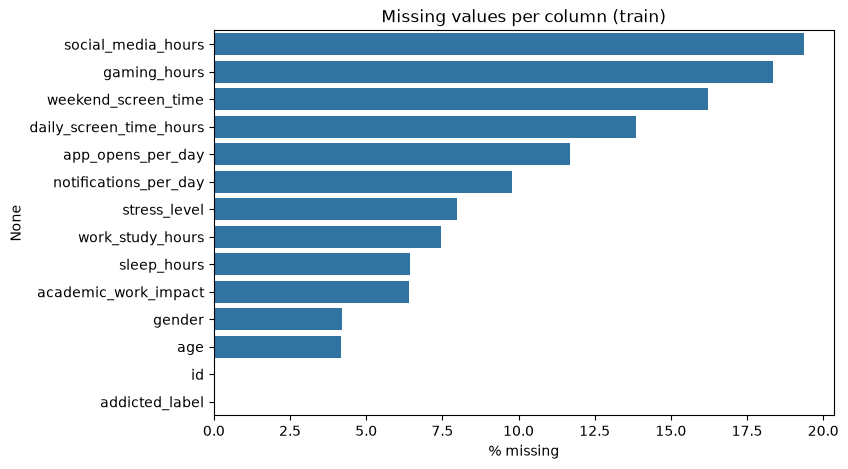

In [4]:
# Missing values per column, sorted, as a percentage of total rows
missing_pct = (train_df.isna().sum() / len(train_df) * 100).sort_values(ascending=False)
print(missing_pct)

# Visualize it
plt.figure(figsize=(8, 5))
sns.barplot(x=missing_pct.values, y=missing_pct.index)
plt.xlabel("% missing")
plt.title("Missing values per column (train)")
plt.show()


In [5]:
# Basic statistics -> helps spot noise / impossible values
# e.g. negative screen time, age = 0 or age = 150, sleep_hours = 40, etc.
train_df.describe(include="all")


,id,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact,addicted_label
count,691369.000000,662440.000000,595515.000000,557374.000000,564548.000000,639851.000000,646889.000000,623785.000000,610659.000000,579306.000000,662335,636221,647145,691369.000000
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,3,2,NaN
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Male,High,Yes,NaN
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,223662,220873,330566,NaN
mean,345684.000000,26.615408,7.640865,2.471038,1.459265,2.366971,6.804334,145.894900,102.636781,9.479866,NaN,NaN,NaN,0.709424
std,199581.183467,5.153162,2.721446,1.316137,0.934552,1.258797,1.234512,65.917556,48.093970,2.856006,NaN,NaN,NaN,0.454028
min,0.000000,18.000000,0.500000,0.000000,0.000000,0.000000,4.500000,20.000000,15.000000,0.510000,NaN,NaN,NaN,0.000000
25%,172842.000000,22.000000,5.480000,1.450000,0.700000,1.360000,5.780000,93.000000,64.000000,7.280000,NaN,NaN,NaN,0.000000
50%,345684.000000,27.000000,7.770000,2.310000,1.330000,2.200000,6.800000,150.000000,104.000000,9.580000,NaN,NaN,NaN,1.000000
75%,518526.000000,31.000000,9.840000,3.370000,2.090000,3.200000,7.870000,204.000000,145.000000,11.750000,NaN,NaN,NaN,1.000000


addicted_label
1    0.709424
0    0.290576
Name: proportion, dtype: float64


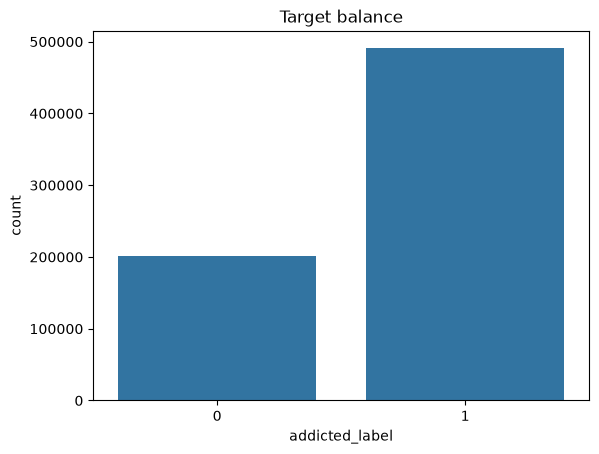

In [6]:
# Check class balance of the target.
# If this is very imbalanced (e.g. 95% / 5%), plain accuracy would be misleading,
# which is exactly why the competition uses ROC-AUC instead of accuracy.
print(train_df["addicted_label"].value_counts(normalize=True))

sns.countplot(x="addicted_label", data=train_df)
plt.title("Target balance")
plt.show()


## 4. Data Cleaning

We clean **train and test the same way**, using rules learned from `train_df` only
(never learn cleaning rules from the test set — that would be "data leakage").

Cleaning steps:
1. **Fix obviously impossible / noisy values** → turn them into missing values (`NaN`), then impute them properly (this is safer than guessing a fixed cutoff and deleting rows, because we cannot afford to lose test rows — every test id needs a prediction).
2. **Impute missing numeric values** with the **median** (median is robust to outliers, unlike the mean).
3. **Impute missing categorical values** (e.g. `gender`) with the **most frequent value** (mode).
4. **Encode categorical columns** into numbers (models need numbers, not text).
5. **Clip extreme outliers** (cap them at a reasonable percentile) instead of deleting rows, so we don't lose test data.
6. **Scale numeric features** (helps Logistic Regression, KNN — tree models don't need it but it doesn't hurt them).

> Important: we NEVER touch `addicted_label` when cleaning features, and we never drop rows from `test_df` (every id in test needs a final prediction, even if some of its values were noisy).


In [7]:
# ---- 4.1 Combine train/test temporarily is NOT what we do (to avoid leakage).
# Instead: we FIT cleaning rules (median, mode, clip bounds) on train_df only,
# then APPLY (transform) those same rules to both train_df and test_df.

# Separate features (X) from target (y) in train
FEATURE_COLS = [c for c in train_df.columns if c not in ["id", "addicted_label"]]
NUMERIC_COLS = [c for c in FEATURE_COLS if train_df[c].dtype != "object"]
CATEGORICAL_COLS = [c for c in FEATURE_COLS if train_df[c].dtype == "object"]

print("Numeric columns:", NUMERIC_COLS)
print("Categorical columns:", CATEGORICAL_COLS)


Numeric columns: ['age', 'daily_screen_time_hours', 'social_media_hours', 'gaming_hours', 'work_study_hours', 'sleep_hours', 'notifications_per_day', 'app_opens_per_day', 'weekend_screen_time', 'gender', 'stress_level', 'academic_work_impact']
Categorical columns: []


In [12]:
# ---- 4.2 Fix impossible / noisy values -> convert to NaN so they get imputed properly
# Adjust these plausible ranges if your dataset's real-world limits are different.
def clean_impossible_values(df):
    df = df.copy()

    # Convert every column used in numeric range checks, including numeric-looking text,
    # so comparisons with numeric limits are always valid.
    numeric_range_cols = [
        "age", "daily_screen_time_hours", "social_media_hours", "gaming_hours",
        "work_study_hours", "sleep_hours", "weekend_screen_time",
        "notifications_per_day", "app_opens_per_day", "stress_level"
    ]
    for col in numeric_range_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    if "age" in df.columns:
        df.loc[(df["age"] < 5) | (df["age"] > 100), "age"] = np.nan
    for col in ["daily_screen_time_hours", "social_media_hours", "gaming_hours",
                "work_study_hours", "sleep_hours", "weekend_screen_time"]:
        if col in df.columns:
            df.loc[(df[col] < 0) | (df[col] > 24), col] = np.nan
    for col in ["notifications_per_day", "app_opens_per_day"]:
        if col in df.columns:
            df.loc[df[col] < 0, col] = np.nan
    if "stress_level" in df.columns:
        # assuming stress_level is on a 1-10 scale; adjust if yours differs
        df.loc[(df["stress_level"] < 0) | (df["stress_level"] > 10), "stress_level"] = np.nan
    return df

train_df = clean_impossible_values(train_df)
test_df  = clean_impossible_values(test_df)

# Refresh these lists because coercion may have changed string columns into numeric columns.
FEATURE_COLS = [c for c in train_df.columns if c not in ["id", "addicted_label"]]
NUMERIC_COLS = [c for c in FEATURE_COLS if pd.api.types.is_numeric_dtype(train_df[c])]
CATEGORICAL_COLS = [c for c in FEATURE_COLS if c not in NUMERIC_COLS]

In [15]:
# ---- 4.3 Impute missing values
# Fit the imputer on TRAIN ONLY, then apply to both train and test (avoids leakage).
# keep_empty_features=True preserves columns that are entirely missing in train.
num_imputer = SimpleImputer(strategy="median", keep_empty_features=True)
train_df[NUMERIC_COLS] = num_imputer.fit_transform(train_df[NUMERIC_COLS])
test_df[NUMERIC_COLS]  = num_imputer.transform(test_df[NUMERIC_COLS])

if CATEGORICAL_COLS:
    cat_imputer = SimpleImputer(strategy="most_frequent", keep_empty_features=True)
    train_df[CATEGORICAL_COLS] = cat_imputer.fit_transform(train_df[CATEGORICAL_COLS])
    test_df[CATEGORICAL_COLS]  = cat_imputer.transform(test_df[CATEGORICAL_COLS])

# Sanity check: no missing values left in the feature columns
print("Missing left in train features:", train_df[FEATURE_COLS].isna().sum().sum())
print("Missing left in test features :", test_df[FEATURE_COLS].isna().sum().sum())

Missing left in train features: 0
Missing left in test features : 0


In [16]:
# ---- 4.4 Encode categorical columns (e.g. gender) into numbers
# LabelEncoder is fit on TRAIN values; unseen categories in test are mapped safely.
encoders = {}
for col in CATEGORICAL_COLS:
    le = LabelEncoder()
    train_df[col] = le.fit_transform(train_df[col].astype(str))
    # map test values through the same encoder; unseen labels -> most frequent train class
    known = set(le.classes_)
    test_df[col] = test_df[col].astype(str).apply(lambda x: x if x in known else le.classes_[0])
    test_df[col] = le.transform(test_df[col])
    encoders[col] = le

print("Encoded categorical columns:", CATEGORICAL_COLS)


Encoded categorical columns: ['gender', 'academic_work_impact']


In [17]:
# ---- 4.5 Clip extreme outliers (cap instead of delete, so test rows are never dropped)
# We cap at the 1st and 99th percentile learned from TRAIN.
clip_bounds = {}
for col in NUMERIC_COLS:
    low, high = train_df[col].quantile(0.01), train_df[col].quantile(0.99)
    clip_bounds[col] = (low, high)
    train_df[col] = train_df[col].clip(low, high)
    test_df[col]  = test_df[col].clip(low, high)   # same bounds, learned from train only


## 5. Feature Engineering

A few extra features often help models pick up patterns that raw columns hide.
 (this is one of the easiest ways to improve ROC-AUC).


In [18]:
def add_features(df):
    df = df.copy()
    # Share of the day spent on screen (captures "addiction intensity")
    df["screen_time_ratio"] = df["daily_screen_time_hours"] / 24
    # Social media as a fraction of all screen time
    df["social_media_ratio"] = df["social_media_hours"] / (df["daily_screen_time_hours"] + 1e-3)
    # Gaming as a fraction of all screen time
    df["gaming_ratio"] = df["gaming_hours"] / (df["daily_screen_time_hours"] + 1e-3)
    # Notifications per hour of screen use (engagement intensity)
    df["notif_per_screen_hour"] = df["notifications_per_day"] / (df["daily_screen_time_hours"] + 1e-3)
    # How much weekend screen time differs from a normal day
    df["weekend_vs_weekday"] = df["weekend_screen_time"] - df["daily_screen_time_hours"]
    # Study/work time vs sleep time balance
    df["work_sleep_ratio"] = df["work_study_hours"] / (df["sleep_hours"] + 1e-3)
    return df

train_df = add_features(train_df)
test_df  = add_features(test_df)

# Update the feature list to include the new engineered features
FEATURE_COLS = [c for c in train_df.columns if c not in ["id", "addicted_label"]]
print("Total features used:", len(FEATURE_COLS))


Total features used: 18


## 6. Train / Validation split

The real `test.csv` has **no labels**, so we can't measure ROC-AUC on it ourselves.
Instead, we carve out part of `train.csv` (e.g. 20%) as a **validation set** that
we treat exactly like the hidden test set — we'll compute ROC-AUC on it after training.

`stratify=y` keeps the same proportion of addicted/not-addicted in both splits.


In [19]:
X = train_df[FEATURE_COLS]
y = train_df["addicted_label"]

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,          # 20% held out for validation
    random_state=RANDOM_STATE,
    stratify=y               # keep class balance the same in both parts
)

print("X_train:", X_train.shape, " X_val:", X_val.shape)


X_train: (553095, 18)  X_val: (138274, 18)


In [20]:
# Scale features (needed for Logistic Regression & KNN; harmless for tree models)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(test_df[FEATURE_COLS])


## 7. Train 5 models and evaluate each with ROC-AUC

For every model we:
1. Train it on `X_train` / `y_train`
2. Predict **probabilities** (not hard 0/1 labels — ROC-AUC needs probabilities) on `X_val`
3. Compute ROC-AUC against the true `y_val`
4. Predict probabilities on the real `test_df` and save a submission file for that model,
   in the exact required format: `id,addicted_label`

Each model's submission is saved to its **own file**, so you can compare them, or submit
whichever one scores best.


In [21]:
results = {}   # will store model_name -> validation ROC-AUC

def evaluate_and_save(name, model, X_tr, X_va, X_te, use_proba_index=1):
    """Train, evaluate on validation with ROC-AUC, and save a submission file."""
    model.fit(X_tr, y_train)

    # Probability of class "1" (addicted) is what ROC-AUC needs
    val_proba = model.predict_proba(X_va)[:, use_proba_index]
    auc = roc_auc_score(y_val, val_proba)
    results[name] = auc
    print(f"{name:22s} -> Validation ROC-AUC = {auc:.4f}")

    # Predict on the real test set and save the submission file
    test_proba = model.predict_proba(X_te)[:, use_proba_index]
    submission = pd.DataFrame({
        "id": test_df["id"],
        "addicted_label": test_proba
    })
    filename = f"submission_{name}.csv"
    submission.to_csv(filename, index=False)
    print(f"  -> saved {filename}")
    return model


### Model 1 — Logistic Regression (0.91724)
A simple, fast linear baseline. Good sanity check: if a strong model can't beat this by much,
your features (not the model) are probably the bottleneck.

**Key parameter — `C`** (inverse of regularization strength):
- Smaller `C` → simpler model, more regularization → helps if the model is **overfitting** (train AUC much higher than validation AUC)
- Larger `C` → more flexible → try increasing if the model is **underfitting** (both train and validation AUC are low)


In [27]:
log_reg = LogisticRegression(
    C=1,                 # <- TUNE THIS. Try 0.01(0.9138), 0.1, 1, 10, 100
    max_iter=1000,
    random_state=RANDOM_STATE
)
_ = evaluate_and_save("logistic_regression", log_reg, X_train_scaled, X_val_scaled, X_test_scaled)


logistic_regression    -> Validation ROC-AUC = 0.9138
  -> saved submission_logistic_regression.csv


### Model 2 — K-Nearest Neighbors (KNN) (20=>0.92355) (27=>0.92586) (35=>0.92712) (50 => )
Predicts based on the `k` most similar rows in the training set. Sensitive to scaling
(that's why we used `X_train_scaled`).

**Key parameter — `n_neighbors` (k)**:
- Smaller `k` (e.g. 3) → very sensitive to noise, can overfit
- Larger `k` (e.g. 50) → smoother decision boundary, can underfit if too large
- **The greater `k`, generally the smoother/more stable — but there's a sweet spot.** Try a range (5, 15, 30, 50) and pick whichever gives the best validation ROC-AUC.


In [36]:
knn = KNeighborsClassifier(
    n_neighbors=300, #<- TUNE THIS. Try 10(0.9116) ,15(0.9182) ,20(0.9213) ,27(0.9234), 35(0.9249), 50(0.9263) ,150(0.9276)
    n_jobs=-1
)
_ = evaluate_and_save("knn", knn, X_train_scaled, X_val_scaled, X_test_scaled)


knn                    -> Validation ROC-AUC = 0.9270
  -> saved submission_knn.csv


### Model 3 — Random Forest
An ensemble of many decision trees, each trained on a random subset of data/features, then averaged.
Usually a strong, fairly robust default.

**Key parameters:**
- `n_estimators` (number of trees) → **the greater, the better** (up to a point of diminishing returns / slower training). Try 100, 300, 500.
- `max_depth` (how deep each tree can grow) → **too high = overfitting** (great train score, worse validation score). Try 5, 10, 20, `None` (unlimited).
- `min_samples_leaf` → **the greater, the more regularized** (helps if overfitting). Try 1, 5, 20.


In [ ]:
rf = RandomForestClassifier(
    n_estimators=750,       # <- TUNE THIS. More trees generally = better, but slower (300/12/5  0.9381) (500/15/8 0.9400)  (750_10_10  0.9362 )
    max_depth=10,            # <- TUNE THIS. Lower if overfitting, higher/None if underfitting
    min_samples_leaf=10,      # <- TUNE THIS. Increase if overfitting
    random_state=RANDOM_STATE,
    n_jobs=-1
)
_ = evaluate_and_save("random_forest", rf, X_train, X_val, test_df[FEATURE_COLS])


random_forest          -> Validation ROC-AUC = 0.9362
  -> saved submission_random_forest.csv


### Model 4 — XGBoost (gradient boosted trees)
Builds trees one after another, each correcting the previous trees' mistakes. Usually
one of the strongest models for tabular data like this.

**Key parameters:**
- `n_estimators` (number of boosting rounds) → **the greater, generally the better**, but pair it with a smaller `learning_rate` to avoid overfitting, and watch validation AUC — if it starts dropping while train AUC keeps rising, you're overfitting.
- `learning_rate` → smaller = more careful/slower learning, usually better final AUC but needs more `n_estimators`. Try 0.3, 0.1, 0.05, 0.01.
- `max_depth` → deeper trees = more complex = higher overfitting risk. Try 3, 5, 7.


In [ ]:
xgb = XGBClassifier(
    n_estimators=650,        # <- TUNE THIS. The greater, generally the better (with small learning_rate) (400_0.05_5  0.9537) (600_0.03_3  0.9418) (650_0.02_6  0.9519) 
    learning_rate=0.02,      # <- TUNE THIS. Smaller = more careful learning
    max_depth=6,              # <- TUNE THIS. Higher = more complex, more overfitting risk
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="auc",
    random_state=RANDOM_STATE,
    n_jobs=-1
)
_ = evaluate_and_save("xgboost", xgb, X_train, X_val, test_df[FEATURE_COLS])


xgboost650             -> Validation ROC-AUC = 0.9519
  -> saved submission_xgboost650.csv


### Model 5 — LightGBM (gradient boosted trees, faster variant)
Similar idea to XGBoost but usually faster on large datasets like this one (691k rows).

**Key parameters:**
- `n_estimators` → **the greater, generally the better**, same trade-off as XGBoost with `learning_rate`.
- `num_leaves` → controls tree complexity. **The greater, the more powerful but also the more prone to overfitting.** Try 15, 31, 63.
- `learning_rate` → smaller = more careful learning, better final result but slower.


In [ ]:
lgbm = LGBMClassifier(
    n_estimators=600,       # <- TUNE THIS. The greater, generally the better (with small learning_rate) (400_0,05_31  0.9586)  (600_0.02_63  0.9589)
    learning_rate=0.02,     # <- TUNE THIS. Smaller = more careful learning
    num_leaves=63,           # <- TUNE THIS. Greater = more powerful but more overfitting risk
    random_state=RANDOM_STATE,
    n_jobs=-1
)
_ = evaluate_and_save("lightgbm600_63", lgbm, X_train, X_val, test_df[FEATURE_COLS])


[LightGBM] [Info] Number of positive: 392379, number of negative: 160716
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.019683 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3465
[LightGBM] [Info] Number of data points in the train set: 553095, number of used features: 17
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.709424 -> initscore=0.892589
[LightGBM] [Info] Start training from score 0.892589
lightgbm600_63         -> Validation ROC-AUC = 0.9589
  -> saved submission_lightgbm600_63.csv


### (Bonus) Model 6 — Gradient Boosting (sklearn)
A 6th model included as an extra comparison point — sklearn's own boosting implementation.

**Key parameters:** same idea as XGBoost/LightGBM — `n_estimators` (greater = better, slower),
`learning_rate` (smaller = more careful), `max_depth` (greater = more overfitting risk).


In [ ]:
gb = GradientBoostingClassifier(
    n_estimators=300,       # <- TUNE THIS (300_0.05_3  0.9403) it tooks 12minutes
    learning_rate=0.05,     # <- TUNE THIS
    max_depth=3,              # <- TUNE THIS
    random_state=RANDOM_STATE
)
_ = evaluate_and_save("gradient_boosting", gb, X_train, X_val, test_df[FEATURE_COLS])


gradient_boosting      -> Validation ROC-AUC = 0.9403
  -> saved submission_gradient_boosting.csv


##  Model 7: CatBoost

    iterations=600,          # <- TUNE THIS. Greater = better, up to diminishing returns (like n_estimators)
    learning_rate=0.03,      # <- TUNE THIS. Smaller = more careful learning, needs more iterations
    depth=6,                  # <- TUNE THIS. Greater = more complex, higher overfitting risk (try 4-8)
    l2_leaf_reg=3,            # <- TUNE THIS. Greater = more regularization, helps if overfitting
    eval_metric="AUC",
    random_state=RANDOM_STATE,
    verbose=False  ========================================== ROC-AUC = 0.9470




    iterations=800,          # <- TUNE THIS. Greater = better, up to diminishing returns (like n_estimators)
    learning_rate=0.02,      # <- TUNE THIS. Smaller = more careful learning, needs more iterations
    depth=4,                  # <- TUNE THIS. Greater = more complex, higher overfitting risk (try 4-8)
    l2_leaf_reg=3,            # <- TUNE THIS. Greater = more regularization, helps if overfitting
    eval_metric="AUC",
    random_state=RANDOM_STATE,
    verbose=False  ========================================== ROC-AUC =0.9413

In [48]:
# CatBoost often beats XGBoost/LightGBM out of the box because it handles
# categorical splits more intelligently and is less prone to overfitting on tabular data.
from catboost import CatBoostClassifier

catboost_model = CatBoostClassifier(
    iterations=800,          # <- TUNE THIS. Greater = better, up to diminishing returns (like n_estimators)
    learning_rate=0.02,      # <- TUNE THIS. Smaller = more careful learning, needs more iterations
    depth=4,                  # <- TUNE THIS. Greater = more complex, higher overfitting risk (try 4-8)
    l2_leaf_reg=3,            # <- TUNE THIS. Greater = more regularization, helps if overfitting
    eval_metric="AUC",
    random_state=RANDOM_STATE,
    verbose=False
)
_ = evaluate_and_save("catboost800", catboost_model, X_train, X_val, test_df[FEATURE_COLS])

catboost800            -> Validation ROC-AUC = 0.9413
  -> saved submission_catboost800.csv


## Model 8: Stacking Ensemble (meta-model)

 This trains a small "meta-model" (Logistic Regression) on top of your best base models' predictions instead of just averaging them — it learns how much to trust each model, which usually beats simple averaging.

In [49]:
from sklearn.ensemble import StackingClassifier

# Pick your strongest base models (adjust based on which scored best for you)
base_models = [
    ("xgb", xgb),
    ("lgbm", lgbm),
    ("catboost", catboost_model),
    ("rf", rf),
]

stack_model = StackingClassifier(
    estimators=base_models,
    final_estimator=LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    cv=5,                # <- TUNE THIS. More folds = more robust meta-training, slower
    n_jobs=-1,
    passthrough=False    # set True to also give the meta-model the raw features (can help or overfit)
)
_ = evaluate_and_save("stacking_ensemble", stack_model, X_train, X_val, test_df[FEATURE_COLS])

KeyboardInterrupt: 

## 8. Compare all models

Sorted from best to worst validation ROC-AUC. Closer to **1.0 is better** (0.5 = random guessing).


In [ ]:
results_df = pd.DataFrame(list(results.items()), columns=["model", "validation_roc_auc"])
results_df = results_df.sort_values("validation_roc_auc", ascending=False).reset_index(drop=True)
print(results_df)

plt.figure(figsize=(8, 5))
sns.barplot(data=results_df, x="validation_roc_auc", y="model")
plt.xlim(0.5, 1.0)
plt.title("Validation ROC-AUC per model (higher = better)")
plt.show()


In [ ]:
# Plot the actual ROC curves of all models together for a visual comparison
plt.figure(figsize=(7, 7))
for name, model in [("logistic_regression", log_reg), ("knn", knn), ("random_forest", rf),
                     ("xgboost", xgb), ("lightgbm", lgbm), ("gradient_boosting", gb)]:
    if name in ["logistic_regression", "knn"]:
        proba = model.predict_proba(X_val_scaled)[:, 1]
    else:
        proba = model.predict_proba(X_val)[:, 1]
    fpr, tpr, _ = roc_curve(y_val, proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC={results[name]:.3f})")

plt.plot([0, 1], [0, 1], "k--", label="random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC curves — all models")
plt.legend()
plt.show()


## 9. How to improve the model — checklist

Use this whenever your ROC-AUC comes back lower than you'd like. Change ONE thing at a time,
re-run, and check if `validation_roc_auc` goes up or down — that tells you if the change helped.

| Symptom | What it means | What to change |
|---|---|---|
| Train AUC is very high, validation AUC is much lower | **Overfitting** | Decrease `max_depth` / `num_leaves`, increase `min_samples_leaf`, decrease `C` (logistic), decrease `n_estimators` or add more regularization |
| Both train AUC and validation AUC are low | **Underfitting** | Increase `max_depth`, increase `n_estimators`, increase `C` (logistic), add more engineered features |
| One model does much better than the others | That model's assumptions fit the data better | Focus tuning time on that model; consider **ensembling** (average the probabilities of your top 2-3 models — often boosts ROC-AUC further) |
| ROC-AUC is stuck no matter what you tune | The **features** are the bottleneck, not the model | Go back to Section 5 and engineer new features (ratios, interactions, binning age/stress_level into groups) |
| Very imbalanced classes | Minority class is hard to learn | Try `class_weight="balanced"` (Logistic Regression, Random Forest) or `scale_pos_weight` (XGBoost/LightGBM) |

**General rule of thumb for "the greater the better" parameters used in this notebook:**
- `n_estimators` (Random Forest, XGBoost, LightGBM, Gradient Boosting) → greater is usually better, at the cost of speed. Watch for diminishing returns.
- `n_neighbors` in KNN → greater smooths the model (reduces noise sensitivity) up to a point, then underfits.
- `C` in Logistic Regression → greater means less regularization (more flexible); too high can overfit.
- `max_depth` / `num_leaves` → greater means more complex model; too high overfits.

Simple ensembling example (often a free boost to ROC-AUC):


In [ ]:
# Example: average XGBoost + LightGBM + Random Forest probabilities (simple ensemble)
val_ensemble = (
    xgb.predict_proba(X_val)[:, 1] +
    lgbm.predict_proba(X_val)[:, 1] +
    rf.predict_proba(X_val)[:, 1]
) / 3

ensemble_auc = roc_auc_score(y_val, val_ensemble)
print(f"Ensemble (xgb+lgbm+rf) validation ROC-AUC = {ensemble_auc:.4f}")

# If this beats the best single model above, save it as a submission too
test_ensemble = (
    xgb.predict_proba(test_df[FEATURE_COLS])[:, 1] +
    lgbm.predict_proba(test_df[FEATURE_COLS])[:, 1] +
    rf.predict_proba(test_df[FEATURE_COLS])[:, 1]
) / 3

submission = pd.DataFrame({"id": test_df["id"], "addicted_label": test_ensemble})
submission.to_csv("submission_ensemble.csv", index=False)
print("-> saved submission_ensemble.csv")


## 10. Final check on a submission file

Quick sanity check before you submit: correct columns, correct row count, probabilities between 0 and 1, no missing ids.


In [ ]:
check = pd.read_csv("submission_xgboost.csv")
print(check.columns.tolist())          # should be [''id'', ''addicted_label'']
print(check.shape)                      # should be (296302, 2)
print(check["addicted_label"].between(0, 1).all())   # should be True
print(check["id"].isna().sum())         # should be 0
check.head()
